# SIR Model Computer Practical
**Understanding Disease Dynamics**

## Learning Objectives
By the end of this practical, you will:
- Understand basic epidemiological modeling concepts
- Implement SIR and SIRD models in Python
- Analyze how parameters affect epidemic outcomes
- Create visualizations of epidemic data

## Instructions for Students
- 🟢 **Code**: Code provided - run and observe
- 🟡 **TODO**: You need to complete these - look for TODO comments
- 🔴 **Question**: Analysis questions you need to answer

**Estimated time: 1-2 hours**

In [1]:
# 🟢 Setup and Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


## Background: SIR Model Basics

The **SIR model** divides population into three compartments:
- **S (Susceptible)**: Can catch the disease  
- **I (Infectious)**: Have disease and can transmit it
- **R (Recovered)**: Recovered and immune

**Mathematical equations:**
- dS/dt = -β × S × I / N
- dI/dt = β × S × I / N - γ × I  
- dR/dt = γ × I

**Key parameters:**
- **β (beta)**: Transmission rate
- **γ (gamma)**: Recovery rate  
- **R₀**: Basic reproduction number = β/γ

## **Exercise 1: Implement Basic SIR Model (20 minutes)**

**Step 1.1: Create the SIR equations**

Your task: Complete the SIR differential equations and create a simulation function.

In [2]:
# 🟡 SIR model function

def sir_model(y, t, beta, gamma):
    """
    SIR model differential equations

    Parameters:
    - y: [S, I, R] populations at time t
    - beta: transmission rate
    - gamma: recovery rate

    Returns:
    - [dS/dt, dI/dt, dR/dt]
    """
    S, I, R = y
    N = S + I + R  # Total population

    # Susceptible people get infected and leave S
    dSdt = -beta * S * I / N
    # Newly infected people come in, recovered people leave
    dIdt = beta * S * I / N - gamma * I
    # Recovered people are the ones who left I
    dRdt = gamma * I

    return dSdt, dIdt, dRdt

# Test your function
print("Testing SIR model function...")
test_result = sir_model([990, 10, 0], 0, 0.3, 0.1)
print(f"Result: {test_result}")
print("If you see three numbers, your function works!")

Testing SIR model function...
Result: (-2.97, 1.9700000000000002, 1.0)
If you see three numbers, your function works!


**Step 1.2: Create simulation and visualization function and run your first simulation**

Now that we have the SIR model equations working, let's create a function to simulate and visualize epidemic scenarios.

This function will:
1. **Set up initial conditions** - most people susceptible, few infectious, none recovered
2. **Solve the differential equations** over time using SciPy's numerical solver
3. **Create a plot** showing how S, I, R populations change over time
4. **Return the results** for further analysis

This is where we'll see our mathematical model come to life as epidemic curves!

Running SIR simulation with β=0.3, γ=0.1
R0 = 3.00


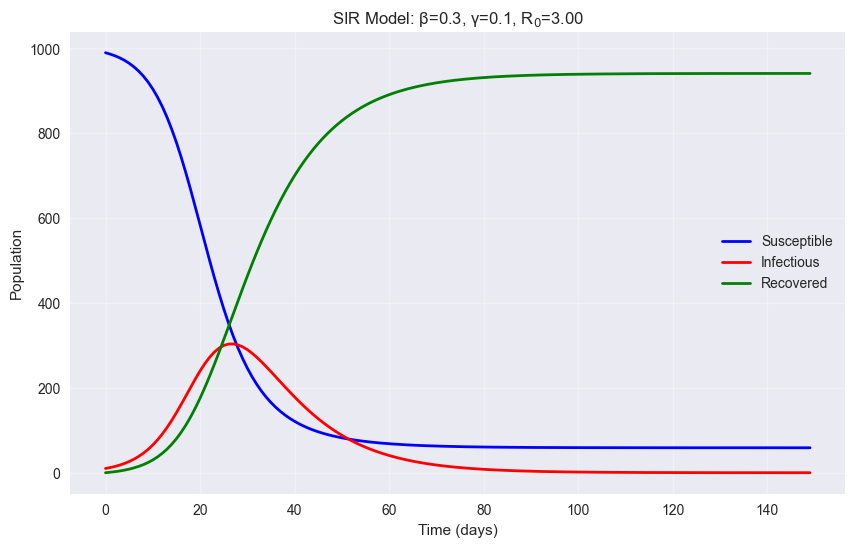

Peak infections: 304 on day 27
Final recovered: 941


In [3]:
# 🟡 Run SIR simulation and create plot

def run_sir_simulation(beta, gamma, N=1000, I0=10, days=150):
    # Initial conditions (provided)
    S0 = N - I0
    R0 = 0
    y0 = [S0, I0, R0]

    # Time points (provided)
    # Note: days - 1 as the endpoint so that t[i] == i exactly
    t = np.linspace(0, days - 1, days)

    # Solve differential equations (provided)
    sol = odeint(sir_model, y0, t, args=(beta, gamma))
    S, I, R = sol.T

    # Create the plot
    plt.figure(figsize=(10, 6))
    # Plot S vs time (blue line, label='Susceptible')
    plt.plot(t, S, 'b-', label='Susceptible', linewidth=2)

    # Plot I vs time (red line, label='Infectious')
    plt.plot(t, I, 'r-', label='Infectious', linewidth=2)

    # Plot R vs time (green line, label='Recovered')
    plt.plot(t, R, 'g-', label='Recovered', linewidth=2)

    plt.xlabel('Time (days)')
    plt.ylabel('Population')
    plt.title(f'SIR Model: β={beta}, γ={gamma}, R$_0$={beta/gamma:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return t, S, I, R

##############################################
# Test your simulation function
##############################################
beta = 0.3
gamma = 0.1

print(f"Running SIR simulation with β={beta}, γ={gamma}")
print(f"R0 = {beta/gamma:.2f}")

t, S, I, R = run_sir_simulation(beta, gamma)

# Calculate and print key results
peak_infected = np.max(I)
peak_day = np.argmax(I)
final_recovered = R[-1]

print(f"Peak infections: {peak_infected:.0f} on day {peak_day}")
print(f"Final recovered: {final_recovered:.0f}")


### 🔴 **Analysis** Questions - TODO: Answer these questions

Try out different beta and gamma values and answer the following question:
*   **What does R₀ > 1 mean for the epidemic?**

    R₀ = β/γ is how many people one infectious person infects on average at the start. R₀ > 1 means
    each sick person infects more than one new person, so cases grow and you get a real epidemic wave.
    If R₀ < 1 the outbreak just dies out.

    Testing this: β=0.3, γ=0.1 (R₀=3) peaks at 304 infectious on day 27, while β=0.05, γ=0.1 (R₀=0.5)
    never rises above the 10 cases we started with.



---



## **Exercise 2: Parameter Exploration (25 minutes)**

Now we'll explore one of the most important aspects of epidemic modeling: **how transmission rate affects epidemic outcomes**.

**Step 2.1: Compare different transmission rates**

We'll systematically test different values of β (transmission rate) while keeping γ (recovery rate) constant. This will help us understand:
- How R₀ values translate to real epidemic behavior
- The relationship between transmission and epidemic severity
- Why small changes in β can have dramatic effects

The following function will run four different scenarios and create both **visual comparisons** and a **quantitative summary table** of key metrics. Go through the code and make sure you understand what happens and how to interpret the plots.

In [ ]:
# 🟢 Compare different transmission rates
def compare_transmission_rates():
    beta_values = [0.1, 0.2, 0.3, 0.4]
    gamma = 0.1

    fig, axes = plt.subplots(4, 2, figsize=(15, 12))
    results = []

    for i, beta in enumerate(beta_values):
        # Run simulation without plotting (just get the data)
        S0, I0, R0 = 990, 10, 0
        t = np.linspace(0, 150, 150)
        sol = odeint(sir_model, [S0, I0, R0], t, args=(beta, gamma))
        S, I, R = sol.T

        # Calculate metrics
        peak_infected = np.max(I)
        peak_day = np.argmax(I)
        final_recovered = R[-1]
        R0 = beta / gamma

        results.append({
            'beta': beta,
            'R0': R0,
            'peak_infected': peak_infected,
            'peak_day': peak_day,
            'final_recovered': final_recovered
        })

        # Left subplot: Full SIR model
        axes[i, 0].plot(t, S, 'b-', label='Susceptible', linewidth=2)
        axes[i, 0].plot(t, I, 'r-', label='Infectious', linewidth=2)
        axes[i, 0].plot(t, R, 'g-', label='Recovered', linewidth=2)
        axes[i, 0].set_title(f'SIR Model: β={beta}, R0={R0:.1f}')
        axes[i, 0].set_xlabel('Time (days)')
        axes[i, 0].set_ylabel('Population')
        axes[i, 0].legend()
        axes[i, 0].grid(True, alpha=0.3)

        # Right subplot: Focus on infectious curve
        axes[i, 1].plot(t, I, 'r-', linewidth=2)
        axes[i, 1].set_title(f'Infectious: Peak={peak_infected:.0f} on day {peak_day}')
        axes[i, 1].set_xlabel('Time (days)')
        axes[i, 1].set_ylabel('Infectious Population')
        axes[i, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    results_df = pd.DataFrame(results)
    print("Parameter Analysis Results:")
    print(results_df.round(1))

    return results_df

results = compare_transmission_rates()

**Step 2.2: Interpretation**

🔴 **Questions** - TODO: Answer these questions

Based on the parameter exploration above, answer the following questions:

1. **How does increasing β affect the epidemic peak?**
   - Your answer here

2. **What happens to epidemic duration as β increases?**
   - Your answer here

3. **Which β value represents the most dangerous scenario?**
   - Your answer here

4. **At what R₀ value does the epidemic become severe?**
   - Your answer here



---



## **Exercise 3: Add Death - SIRD Model (25 minutes)**

**Step 3.1: Implement SIRD model**

Real diseases don't just result in recovery - unfortunately, some infectious individuals die. The **SIRD model** extends our SIR framework by adding a fourth compartment: **D (Deceased)**.

**Key changes:**
- Infectious individuals can now follow **two pathways**: recover (rate γ) OR die (rate μ)
- We track cumulative deaths over time
- This gives us more realistic epidemic outcomes and allows us to evaluate interventions in terms of **lives saved**

**Mathematical modification:**
- The infectious equation becomes: dI/dt = βSI/N - γI - μI
- We add a new equation: dD/dt = μI

This extension will help us understand how case fatality rates affect epidemic dynamics and evaluate the true impact of public health interventions.

In [ ]:
# 🟡 adapt the differential equations for the extended model
def sird_model(y, t, beta, gamma, mu):
    """
    SIRD model with death compartment

    TODO: Adapt the SIR model to include deaths

    Additional parameter:
    - mu: mortality rate

    New compartment:
    - D: Deaths
    """
    S, I, R, D = y  # Note: now 4 compartments
    N = S + I + R + D

    # TODO: Modify the SIR equations to include death
    # Hint: Infectious people can either recover (rate γ) OR die (rate μ)

    dSdt = # TODO: Same as SIR
    dIdt = # TODO: SIR equation minus deaths (- mu * I)
    dRdt = # TODO: Same as SIR
    dDdt = # TODO: New equation for deaths

    return dSdt, dIdt, dRdt, dDdt

# Test your SIRD function
test_result = sird_model([990, 10, 0, 0], 0, 0.3, 0.1, 0.01)
print(f"SIRD test result: {test_result}")
print("You should see 4 numbers!")

Now let's define the SIRD simulation function — we'll call it in the next step to actually run and compare it against the SIR model.

In [ ]:
# 🟡 add a new line in the plot
def run_sird_simulation(beta, gamma, mu, N=1000, I0=10, days=150):

    # TODO: Set up initial conditions with 4 compartments
    S0 = N - I0
    R0 = 0
    D0 = # TODO: Initial deaths
    y0 = [S0, I0, R0, D0]

    # Time points (same as before)
    # Note: days - 1 as the endpoint so that t[i] == i exactly
    t = np.linspace(0, days - 1, days)

    # TODO: Solve SIRD equations (adapt from SIR)
    sol = odeint(# TODO: use sird_model instead of sir_model)
    S, I, R, D = sol.T

    # TODO: Create plot with 4 lines
    plt.figure(figsize=(10, 6))
    plt.plot(t, S, 'b-', label='Susceptible', linewidth=2)
    plt.plot(t, I, 'r-', label='Infectious', linewidth=2)
    plt.plot(t, R, 'g-', label='Recovered', linewidth=2)
    plt.plot(# TODO: add deaths plot - black line)

    plt.xlabel('Time (days)')
    plt.ylabel('Population')
    plt.title(f'SIRD Model: β={beta}, γ={gamma}, μ={mu}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return t, S, I, R, D

**Step 3.2:  Compare SIR vs SIRD**

Now let's compare the differences between SIR and SIRD model. How are the dynamics changed?


In [ ]:
# 🟡 calculate number of recovered
beta, gamma, mu = 0.3, 0.1, 0.01

print("SIR Model (no deaths):")
t_sir, S_sir, I_sir, R_sir = run_sir_simulation(beta, gamma)

print("\nSIRD Model (with deaths):")
t_sird, S_sird, I_sird, R_sird, D_sird = run_sird_simulation(beta, gamma, mu)

# TODO: Calculate and compare final outcomes
print(f"\nComparison after {len(t_sir)} days:")
print(f"SIR  - Recovered: {R_sir[-1]:.0f}")
print(f"SIRD - Recovered: {# TODO}, Deaths: {# TODO}")

# TODO: Calculate mortality rate
mortality_rate = # TODO: deaths / (deaths + recovered) * 100
print(f"Mortality rate: {mortality_rate:.1f}%")

**Step 3.3: Interpretation**

🔴 **Questions** - TODO: Answer these questions

Try out different mortality rates and try to see the effect.

1. **How does mortality rate affect total deaths?**
   - Your answer here

2. **Does mortality rate affect the epidemic curve shape?**
   - Your answer here




---



## **Exercise 4: Real-World Application (25 minutes)**

**Step 4.1: Model a realistic scenario**

Now let's apply our SIRD model to a **COVID-19-inspired scenario** with realistic parameters. This will help us understand how our mathematical models translate to real-world epidemics.

We'll use estimated parameters based on early COVID-19 data:
- **Higher transmission rate** (β = 0.5) reflecting the highly contagious nature
- **Longer recovery time** (~10 days average)
- **Realistic mortality rate** (~2%)
- **Larger population** (10,000 people) to see clearer patterns

This scenario will show us the potential scale and timeline of an uncontrolled epidemic.

In [ ]:
# 🟢 run this model to run a COVID-inspired model
def model_covid_scenario():
    # Estimated parameters (simplified)
    beta = 0.5      # High transmission
    gamma = 1/10    # ~10 day recovery period
    mu = 0.02       # ~2% mortality rate

    N = 10000       # Larger population
    I0 = 50         # Multiple initial cases
    days = 365      # One year

    print("COVID-19 Scenario Parameters:")
    print(f"R0 = {beta/gamma:.2f}")
    print(f"Average recovery time: {1/gamma:.0f} days")
    print(f"Mortality rate: {mu*100:.1f}%")

    t, S, I, R, D = run_sird_simulation(beta, gamma, mu, N, I0, days)

    print(f"\nAfter 1 year:")
    print(f"Total infected: {(R[-1] + D[-1]):.0f} ({(R[-1] + D[-1])/N*100:.1f}%)")
    print(f"Deaths: {D[-1]:.0f} ({D[-1]/N*100:.2f}%)")
    print(f"Peak infections: {max(I):.0f} on day {np.argmax(I)}")

    return t, S, I, R, D

# Run COVID scenario
covid_results = model_covid_scenario()

**Step 4.2: Intervention analysis**

Public health interventions like social distancing, mask mandates, or lockdowns primarily work by **reducing transmission rates**. Let's quantify how effective these interventions can be.

We'll compare two scenarios:
- **No intervention**: High transmission (β = 0.5)
- **With intervention**: Reduced transmission (β = 0.3) representing a 40% reduction

This analysis will help us calculate concrete metrics like **lives saved**, **peak reduction**, and **intervention effectiveness** - the kind of analysis that informs real policy decisions.

In [ ]:
# 🟢 investigate intervention effect
def compare_intervention():

    # Parameters
    gamma, mu = 1/10, 0.02
    N, I0, days = 10000, 50, 365

    beta_no_intervention = 0.5
    beta_with_intervention = 0.3 # 40% reduction in transmission

    print("Scenario 1: No intervention")
    t1, S1, I1, R1, D1 = run_sird_simulation(beta_no_intervention, gamma, mu, N, I0, days)

    print("\nScenario 2: With intervention")
    t2, S2, I2, R2, D2 = run_sird_simulation(beta_with_intervention, gamma, mu, N, I0, days)

    # Plot infectious populations
    plt.plot(t1, I1, 'r-', label='Infectious - No intervention', linewidth=2)
    plt.plot(t2, I2, 'b-', label='Infectious - With intervention', linewidth=2)

    # Plot deaths (cumulative)
    plt.plot(t1, D1, 'r:', label='Deaths - No intervention', linewidth=2)
    plt.plot(t2, D2, 'b:', label='Deaths - With intervention', linewidth=2)

    plt.xlabel('Time (days)')
    plt.ylabel('Population')
    plt.title('Intervention Impact: Infections and Deaths Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Summary comparison
    print(f"\nIntervention Impact:")
    print(f"Deaths prevented: {D1[-1] - D2[-1]:.0f}")
    print(f"Peak reduction: {max(I1) - max(I2):.0f} fewer peak infections")
    print(f"Lives saved: {((D1[-1] - D2[-1])/D1[-1])*100:.1f}% reduction in deaths")
    print(f"Peak delay: {np.argmax(I2) - np.argmax(I1)} days")

compare_intervention()

**Step 4.3: Interpretation**

🔴 **Questions** - TODO: Answer based on your COVID-19 scenario and intervention analysis:

1. **COVID-19 scenario interpretation:**
   - What percentage of the population gets infected in the uncontrolled scenario?
        - Your answer
   - How does the timeline compare to what we observed in real COVID-19 outbreaks?
        - Your answer

2. **Intervention effectiveness:**
   - How many lives were saved by the 40% transmission reduction?
        - Your answer
   - What was the percentage reduction in peak infections?
        - Your answer
   - By how many days was the epidemic peak delayed?
        - Your answer

3. **Policy implications:**
   - If you were a public health official, what would you conclude about the value of interventions that reduce transmission by 40%?
        - Your answer
   - What are the trade-offs between intervention strength and epidemic outcomes?
        - Your answer

4. **Model limitations:**
   - What aspects of real COVID-19 outbreaks does our model miss?
        - Your answer


---

## **Exercise 5 (Optional): The Endemic SIR Model (20-25 minutes)**

*This exercise is optional and not graded. It's for anyone curious about what happens to a disease over the long run, once births and natural deaths are taken into account.*

**Step 5.1: Background — why do some diseases never disappear?**

In every model so far, the epidemic always burns out: once the pool of susceptibles is used up, infections decline and eventually stop. But diseases like measles, chickenpox, or seasonal flu don't disappear — they keep circulating in the population indefinitely. Why?

The missing ingredient is **demography**: new susceptible individuals are constantly born, replenishing the pool that the disease depletes. If we add births and natural deaths to the SIR model, the epidemic no longer has to end — it can settle into a stable **endemic equilibrium**, where the disease persists at a roughly constant level forever.

**New parameter:**
- **ν (nu)**: the natural birth/death rate of the population (assumed equal, so total population N stays constant over time)

**Modified equations:**
- dS/dt = νN − βSI/N − νS
- dI/dt = βSI/N − γI − νI
- dR/dt = γI − νR

Notice the two new terms: `νN` (new susceptible births) and `−νS`, `−νI`, `−νR` (natural deaths removing individuals from each compartment at the same rate).

**Endemic reproduction number:**

With demography, the effective R₀ becomes:

R₀ = β / (γ + ν)

If R₀ > 1, the disease persists at an endemic equilibrium. If R₀ ≤ 1, it still dies out, just as before.

In [ ]:
# 🟡 SIR model with vital dynamics (births and natural deaths)

def sir_endemic_model(y, t, beta, gamma, nu):
    """
    SIR model with births and natural deaths (vital dynamics)

    Parameters:
    - y: [S, I, R] populations at time t
    - beta: transmission rate
    - gamma: recovery rate
    - nu: natural birth/death rate

    Returns:
    - [dS/dt, dI/dt, dR/dt]
    """
    S, I, R = y
    N = S + I + R  # Total population (stays ~constant)

    # TODO: Implement the three differential equations
    # Hint: start from the SIR equations, then add a birth term to dS/dt
    # and a "- nu * X" natural-death term to each compartment

    dSdt = # TODO
    dIdt = # TODO
    dRdt = # TODO

    return dSdt, dIdt, dRdt

# Test your function
test_result = sir_endemic_model([990, 10, 0], 0, 0.3, 0.1, 0.001)
print(f"Result: {test_result}")
print("If you see three numbers, your function works!")

**Step 5.2: Run a long simulation**

Endemic dynamics take much longer to play out than a single epidemic wave — we need years, not days, to see the population settle into equilibrium.

In [ ]:
# 🟡 Run the endemic simulation over several years

def run_endemic_simulation(beta, gamma, nu, N=1000, I0=10, years=20):
    S0 = N - I0
    R0 = 0
    y0 = [S0, I0, R0]

    days = years * 365
    t = np.linspace(0, days - 1, days)

    # TODO: solve the endemic model (adapt from earlier exercises)
    sol = odeint(# TODO: use sir_endemic_model instead of sir_model)
    S, I, R = sol.T

    plt.figure(figsize=(10, 6))
    plt.plot(t / 365, S, 'b-', label='Susceptible', linewidth=2)
    plt.plot(t / 365, I, 'r-', label='Infectious', linewidth=2)
    plt.plot(t / 365, R, 'g-', label='Recovered', linewidth=2)
    plt.xlabel('Time (years)')
    plt.ylabel('Population')
    plt.title(f'Endemic SIR Model: β={beta}, γ={gamma}, ν={nu}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return t, S, I, R

beta, gamma, nu = 0.3, 0.1, 0.001
t, S, I, R = run_endemic_simulation(beta, gamma, nu)

**Step 5.3: Compare simulation to the theoretical equilibrium**

In [ ]:
# 🟢 Calculate and overlay the theoretical endemic equilibrium

def endemic_equilibrium(beta, gamma, nu, N):
    R0 = beta / (gamma + nu)
    S_star = N / R0
    I_star = (nu * N / (gamma + nu)) * (1 - 1 / R0)
    return R0, S_star, I_star

N = 1000
R0, S_star, I_star = endemic_equilibrium(beta, gamma, nu, N)

print(f"R0 (with demography) = {R0:.2f}")
print(f"Theoretical equilibrium: S* = {S_star:.0f}, I* = {I_star:.0f}")
print(f"Simulated final values:  S  = {S[-1]:.0f}, I  = {I[-1]:.0f}")

**Step 5.4: Interpretation**

🔴 **Questions** - Answer these questions

1. **Why doesn't the infectious curve go to zero here, unlike in Exercise 1?**
   - Your answer here

2. **What does the condition R₀ = β/(γ+ν) > 1 mean biologically?**
   - Your answer here

3. **Try lowering ν toward 0. What happens to the endemic equilibrium, and why does this make sense?**
   - Your answer here

4. **Name one real disease that behaves this way (stays endemic rather than dying out), and explain what role you think births/population turnover play in keeping it circulating.**
   - Your answer here